# 7.2. 구면 위 입자

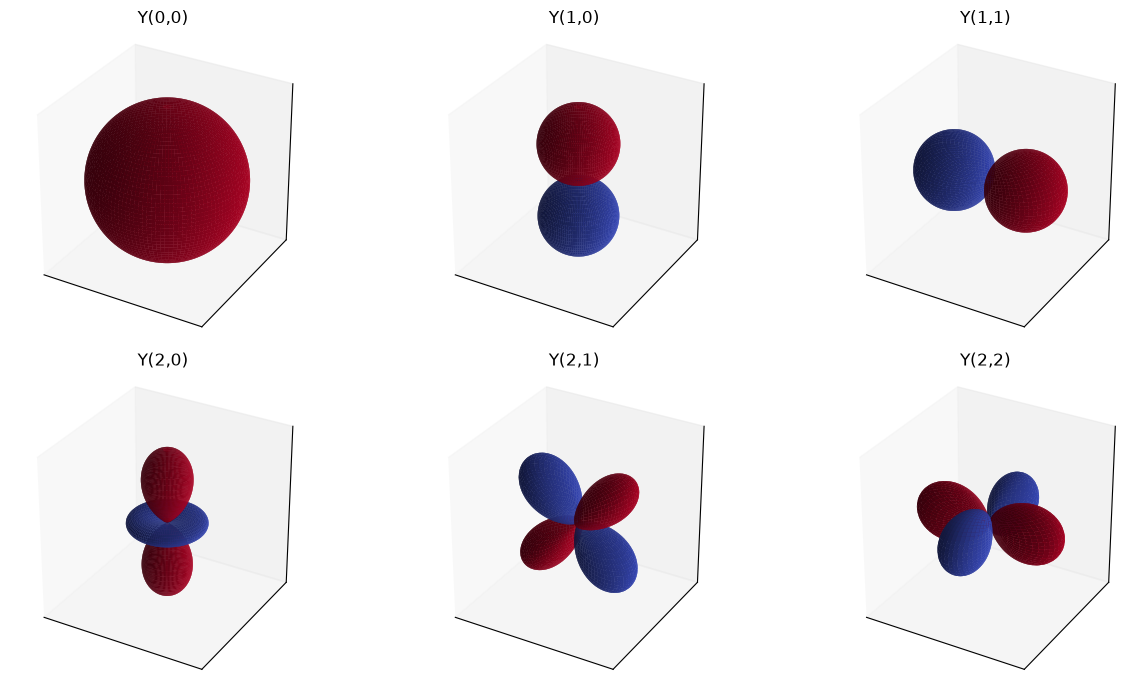

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm_y


def real_Y(l, m, theta, phi):
    """실수형 구면조화함수 (그리기 편하도록)"""
    if m == 0:
        return sph_harm_y(l, 0, theta, phi).real
    elif m > 0:
        return np.sqrt(2) * (-1) ** m * sph_harm_y(l, m, theta, phi).real
    else:
        return np.sqrt(2) * (-1) ** m * sph_harm_y(l, -m, theta, phi).imag


theta = np.linspace(0, np.pi, 120)
phi = np.linspace(0, 2 * np.pi, 240)
T, P = np.meshgrid(theta, phi, indexing="ij")

states = [
    (0, 0, "Y(0,0)"),
    (1, 0, "Y(1,0)"),
    (1, 1, "Y(1,1)"),
    (2, 0, "Y(2,0)"),
    (2, 1, "Y(2,1)"),
    (2, 2, "Y(2,2)"),
]

fig = plt.figure(figsize=(13, 7))
for i, (l, m, title) in enumerate(states, 1):
    ax = fig.add_subplot(2, 3, i, projection="3d")
    Y = real_Y(l, m, T, P)
    R = np.abs(Y)
    X = R * np.sin(T) * np.cos(P)
    Yc = R * np.sin(T) * np.sin(P)
    Z = R * np.cos(T)
    colors = plt.cm.coolwarm((np.sign(Y) + 1) / 2)
    ax.plot_surface(X, Yc, Z, facecolors=colors, rstride=2, cstride=2, linewidth=0)
    lim = R.max() * 1.1
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_box_aspect((1, 1, 1))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

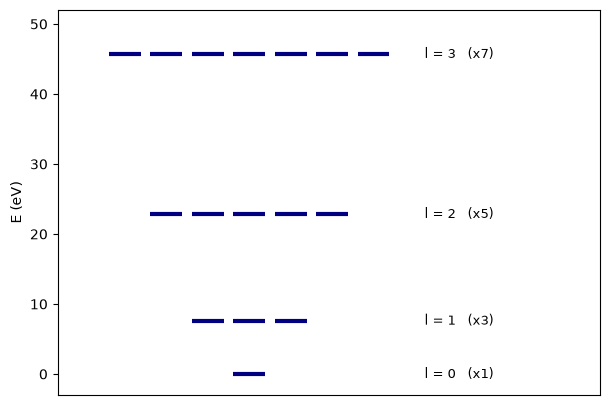

l = 0: E =   0.0000 eV,  m = [0],  축퇴 1
l = 1: E =   7.6200 eV,  m = [-1, 0, 1],  축퇴 3
l = 2: E =  22.8599 eV,  m = [-2, -1, 0, 1, 2],  축퇴 5
l = 3: E =  45.7198 eV,  m = [-3, -2, -1, 0, 1, 2, 3],  축퇴 7


In [2]:
from scipy.constants import hbar, m_e, e

r = 1e-10
B = hbar**2 / (2 * m_e * r**2) / e

fig, ax = plt.subplots(figsize=(7, 5))
for l in range(4):
    E = l * (l + 1) * B
    g = 2 * l + 1
    for j in range(g):
        x0 = 0.5 + (j - (g - 1) / 2) * 0.13
        ax.hlines(E, x0 - 0.05, x0 + 0.05, lw=3, color="navy")
    ax.text(1.05, E, f"l = {l}   (x{g})", va="center", fontsize=9)

ax.set_xlim(-0.1, 1.6)
ax.set_ylim(-3, 52)
ax.set_xticks([])
ax.set_ylabel("E (eV)")
plt.show()

for l in range(4):
    print(
        f"l = {l}: E = {l*(l+1)*B:8.4f} eV,  m = {list(range(-l, l+1))},  축퇴 {2*l+1}"
    )